In [1]:
import pandas as pd

In [2]:
RH = pd.read_excel(r'/home/khalid/Desktop/Cours_internes/Projet_12/Données_RH.xlsx')
SPORT = pd.read_excel(r'/home/khalid/Desktop/Cours_internes/Projet_12/Données_Sportive.xlsx')


In [3]:
RH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID salarié             161 non-null    int64         
 1   Nom                    161 non-null    object        
 2   Prénom                 161 non-null    object        
 3   Date de naissance      161 non-null    datetime64[ns]
 4   BU                     161 non-null    object        
 5   Date d'embauche        161 non-null    datetime64[ns]
 6   Salaire brut           161 non-null    int64         
 7   Type de contrat        161 non-null    object        
 8   Nombre de jours de CP  161 non-null    int64         
 9   Adresse du domicile    161 non-null    object        
 10  Moyen de déplacement   161 non-null    object        
dtypes: datetime64[ns](2), int64(3), object(6)
memory usage: 14.0+ KB


In [4]:
RH.shape

(161, 11)

In [5]:
RH.head(5)

,ID salarié,Nom,Prénom,Date de naissance,BU,Date d'embauche,Salaire brut,Type de contrat,Nombre de jours de CP,Adresse du domicile,Moyen de déplacement
0,59019,Colin,Audrey,1990-07-06,Marketing,2020-12-14,30940,CDI,29,"128 Rue du Port, 34000 Frontignan",Transports en commun
1,19841,Ledoux,Monique,1962-01-06,R&D,2020-07-07,74360,CDI,26,"68 Rue du Port, 34970 Saint-Clément-de-Rivière",véhicule thermique/électrique
2,56482,Dumont,Michelle,1976-08-09,Ventes,2022-03-29,51390,CDI,27,"100 Av. de la Gare, 30900 Nîmes",véhicule thermique/électrique
3,21886,Toussaint,Judith,1962-09-10,Support,2021-12-12,70320,CDI,29,"53 Av. de la Gare, 34970 Lattes",Marche/running
4,81001,Bailly,Michelle,1975-04-20,Ventes,2025-02-19,46870,CDD,29,"74 Rue des Fleurs, 34970 Lattes",Marche/running


In [6]:
SPORT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID salarié           161 non-null    int64 
 1   Pratique d'un sport  95 non-null     object
dtypes: int64(1), object(1)
memory usage: 2.6+ KB


In [7]:
SPORT.shape

(161, 2)

In [8]:
SPORT.head(5)

,ID salarié,Pratique d'un sport
0,59019,NaN
1,19841,NaN
2,56482,Tennis
3,21886,NaN
4,81001,NaN


In [9]:
SPORT['Pratique d\'un sport'].isna().sum()

np.int64(66)

In [10]:
SPORT['Pratique d\'un sport'].isna().mean()*100

np.float64(40.993788819875775)

In [11]:
SPORT['Pratique d\'un sport'] = SPORT['Pratique d\'un sport'].fillna('Aucun')

In [12]:
SPORT.head(5)

,ID salarié,Pratique d'un sport
0,59019,Aucun
1,19841,Aucun
2,56482,Tennis
3,21886,Aucun
4,81001,Aucun


In [13]:
SPORT['Pratique d\'un sport'].value_counts()

Pratique d'un sport
Aucun              66
Runing             18
Randonnée          16
Tennis             11
Natation            8
Football            6
Rugby               6
Badminton           5
Voile               5
Boxe                4
Judo                4
Escalade            3
Triathlon           3
Équitation          2
Tennis de table     2
Basketball          2
Name: count, dtype: int64

In [14]:
SPORT['Pratique d\'un sport'].nunique()

16

In [15]:
SPORT['Pratique d\'un sport'].unique()

array(['Aucun', 'Tennis', 'Badminton', 'Escalade', 'Randonnée',
       'Triathlon', 'Runing', 'Équitation', 'Voile', 'Tennis de table',
       'Football', 'Natation', 'Judo', 'Basketball', 'Rugby', 'Boxe'],
      dtype=object)

In [16]:
SPORT["Pratique d\'un sport"] = SPORT["Pratique d\'un sport"].replace('Runing', 'Running')

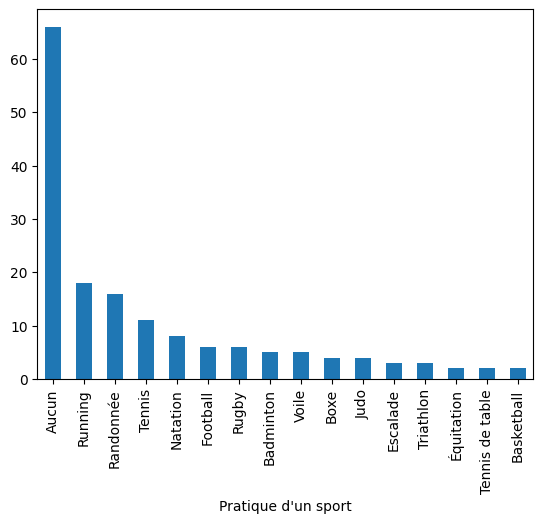

In [17]:
import matplotlib.pyplot as plt

SPORT['Pratique d\'un sport'].value_counts().plot(kind='bar')
plt.show()

In [18]:
df = RH.merge(SPORT, on="ID salarié", how="left")

In [19]:
print(df['ID salarié'].nunique())  

161


In [20]:
df.head(5)

,ID salarié,Nom,Prénom,Date de naissance,BU,Date d'embauche,Salaire brut,Type de contrat,Nombre de jours de CP,Adresse du domicile,Moyen de déplacement,Pratique d'un sport
0,59019,Colin,Audrey,1990-07-06,Marketing,2020-12-14,30940,CDI,29,"128 Rue du Port, 34000 Frontignan",Transports en commun,Aucun
1,19841,Ledoux,Monique,1962-01-06,R&D,2020-07-07,74360,CDI,26,"68 Rue du Port, 34970 Saint-Clément-de-Rivière",véhicule thermique/électrique,Aucun
2,56482,Dumont,Michelle,1976-08-09,Ventes,2022-03-29,51390,CDI,27,"100 Av. de la Gare, 30900 Nîmes",véhicule thermique/électrique,Tennis
3,21886,Toussaint,Judith,1962-09-10,Support,2021-12-12,70320,CDI,29,"53 Av. de la Gare, 34970 Lattes",Marche/running,Aucun
4,81001,Bailly,Michelle,1975-04-20,Ventes,2025-02-19,46870,CDD,29,"74 Rue des Fleurs, 34970 Lattes",Marche/running,Aucun


In [21]:
df.groupby('BU')["Pratique d'un sport"].value_counts(normalize=True)*100

BU         Pratique d'un sport
Finance    Aucun                  35.714286
           Running                16.666667
           Randonnée               7.142857
           Rugby                   7.142857
           Badminton               4.761905
           Football                4.761905
           Judo                    4.761905
           Tennis                  4.761905
           Voile                   4.761905
           Basketball              2.380952
           Boxe                    2.380952
           Escalade                2.380952
           Natation                2.380952
Marketing  Aucun                  48.000000
           Randonnée              12.000000
           Natation                8.000000
           Running                 8.000000
           Tennis                  8.000000
           Boxe                    4.000000
           Escalade                4.000000
           Triathlon               4.000000
           Équitation              4.000000
R

In [22]:
df.groupby("Moyen de déplacement")["Pratique d'un sport"].value_counts()

Moyen de déplacement           Pratique d'un sport
Marche/running                 Aucun                   6
                               Randonnée               2
                               Running                 2
                               Badminton               1
                               Football                1
                               Natation                1
                               Tennis                  1
Transports en commun           Aucun                   8
                               Running                 4
                               Randonnée               2
                               Triathlon               2
                               Voile                   2
                               Natation                1
                               Équitation              1
Vélo/Trottinette/Autres        Aucun                  25
                               Natation                5
                               Randon

In [23]:
df.groupby("Moyen de déplacement")["Pratique d'un sport"].value_counts(normalize=True)*100

Moyen de déplacement           Pratique d'un sport
Marche/running                 Aucun                  42.857143
                               Randonnée              14.285714
                               Running                14.285714
                               Badminton               7.142857
                               Football                7.142857
                               Natation                7.142857
                               Tennis                  7.142857
Transports en commun           Aucun                  40.000000
                               Running                20.000000
                               Randonnée              10.000000
                               Triathlon              10.000000
                               Voile                  10.000000
                               Natation                5.000000
                               Équitation              5.000000
Vélo/Trottinette/Autres        Aucun                 

In [24]:
df["age"] = (pd.Timestamp("today") - df["Date de naissance"]).dt.days // 365

In [25]:
df["age"].nunique()

43

In [26]:
df.groupby("age")["Pratique d'un sport"].value_counts(normalize=True)*100

age  Pratique d'un sport
23   Judo                   100.000000
24   Aucun                   25.000000
     Judo                    25.000000
     Rugby                   25.000000
     Running                 25.000000
                               ...    
64   Natation                16.666667
     Running                 16.666667
65   Aucun                   66.666667
     Badminton               16.666667
     Rugby                   16.666667
Name: proportion, Length: 118, dtype: float64

In [27]:
bins = [0, 30, 40, 50, 100]

labels = ["<30", "30-40", "40-50", "50+"]

df["tranche_age"] = pd.cut(df["age"], bins=bins, labels=labels)

In [28]:
df.head()

,ID salarié,Nom,Prénom,Date de naissance,BU,Date d'embauche,Salaire brut,Type de contrat,Nombre de jours de CP,Adresse du domicile,Moyen de déplacement,Pratique d'un sport,age,tranche_age
0,59019,Colin,Audrey,1990-07-06,Marketing,2020-12-14,30940,CDI,29,"128 Rue du Port, 34000 Frontignan",Transports en commun,Aucun,35,30-40
1,19841,Ledoux,Monique,1962-01-06,R&D,2020-07-07,74360,CDI,26,"68 Rue du Port, 34970 Saint-Clément-de-Rivière",véhicule thermique/électrique,Aucun,64,50+
2,56482,Dumont,Michelle,1976-08-09,Ventes,2022-03-29,51390,CDI,27,"100 Av. de la Gare, 30900 Nîmes",véhicule thermique/électrique,Tennis,49,40-50
3,21886,Toussaint,Judith,1962-09-10,Support,2021-12-12,70320,CDI,29,"53 Av. de la Gare, 34970 Lattes",Marche/running,Aucun,63,50+
4,81001,Bailly,Michelle,1975-04-20,Ventes,2025-02-19,46870,CDD,29,"74 Rue des Fleurs, 34970 Lattes",Marche/running,Aucun,50,40-50


In [29]:
df.groupby("tranche_age", observed=True)["Pratique d'un sport"].value_counts(normalize=True)*100

tranche_age  Pratique d'un sport
<30          Aucun                  29.166667
             Randonnée              20.833333
             Running                12.500000
             Judo                    8.333333
             Tennis                  8.333333
             Basketball              4.166667
             Escalade                4.166667
             Football                4.166667
             Natation                4.166667
             Rugby                   4.166667
30-40        Aucun                  37.142857
             Running                14.285714
             Randonnée              11.428571
             Rugby                   5.714286
             Voile                   5.714286
             Boxe                    2.857143
             Escalade                2.857143
             Football                2.857143
             Judo                    2.857143
             Natation                2.857143
             Tennis                  2.857143
 

In [30]:
df["Salaire brut"].describe()

count      161.000000
mean     50426.273292
std      14779.614627
min      25570.000000
25%      37910.000000
50%      50580.000000
75%      62760.000000
max      74990.000000
Name: Salaire brut, dtype: float64